# Music Genre Classification: Dilated CNN + Classical Algorithms
**UE24CS352A Machine Learning, Mini-Project**

Pipeline: GTZAN (5 genres) -> MFCC -> baselines (LR, GDA, RF, SVM) -> Dilated CNN -> CNN layer activations as features for the classical models -> comparison.

Based on: *Combining CNN and Classical Algorithms for Music Genre Classification* (Li, Xue, Zhang, Stanford).

## 1. Setup

In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa

warnings.filterwarnings("ignore")

REPO_URL = "https://github.com/NanditaPatil-dotcom/ml_mini_project.git"
REPO_DIR = "/content/ml_mini_project"

# Clone the repo (dataset is inside it). If the repo is private, use:
# https://<YOUR_TOKEN>@github.com/NanditaPatil-dotcom/ml_mini_project.git
if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}

Cloning into '/content/ml_mini_project'...
remote: Enumerating objects: 542, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 542 (delta 6), reused 35 (delta 4), pack-reused 501 (from 2)
Receiving objects: 100% (542/542), 268.00 MiB | 31.07 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Updating files: 100% (504/504), done.


## 2. Configuration

In [2]:
SEED       = 42
GENRES     = ["blues", "classical", "hiphop", "metal", "pop"]
SR         = 22050      # sample rate
N_MFCC     = 20         # MFCC coefficients per frame
N_FRAMES   = 560        # ~13 s clips at hop 512 -> fixed length
DATA_DIR   = f"{REPO_DIR}/dataset/gtzan_trimmed"
FEAT_DIR   = f"{REPO_DIR}/features"
MODEL_DIR  = f"{REPO_DIR}/models"
RES_DIR    = f"{REPO_DIR}/results"
SCALE_FEATURES = False  # paper does not mention scaling; set True to compare as an extra experiment

for d in (FEAT_DIR, MODEL_DIR, RES_DIR):
    os.makedirs(d, exist_ok=True)

random.seed(SEED); np.random.seed(SEED)

for g in GENRES:
    n = len([f for f in os.listdir(f"{DATA_DIR}/{g}") if f.endswith(".wav")])
    print(f"{g:10s} {n} clips")

blues      100 clips
classical  100 clips
hiphop     100 clips
metal      100 clips
pop        100 clips


## 3. MFCC extraction
Each clip becomes a `(time, 20)` array, padded or cropped to `N_FRAMES`. Cached to `features/mfcc_features.npz` so it only runs once.

In [3]:
def extract_mfcc(path):
    y, _ = librosa.load(path, sr=SR)
    m = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC)      # (20, T)
    if m.shape[1] < N_FRAMES:
        m = np.pad(m, ((0, 0), (0, N_FRAMES - m.shape[1])))
    return m[:, :N_FRAMES].T                                  # (N_FRAMES, 20)

cache = f"{FEAT_DIR}/mfcc_features.npz"
if os.path.exists(cache):
    d = np.load(cache, allow_pickle=True)
    X, y = d["X"], d["y"]
    print("Loaded cached features")
else:
    X, y = [], []
    for label, g in enumerate(GENRES):
        for f in sorted(os.listdir(f"{DATA_DIR}/{g}")):
            if f.endswith(".wav"):
                X.append(extract_mfcc(f"{DATA_DIR}/{g}/{f}"))
                y.append(label)
    X, y = np.array(X, dtype=np.float32), np.array(y)
    np.savez_compressed(cache, X=X, y=y, genres=np.array(GENRES))

print("X:", X.shape, " y:", y.shape, " classes:", np.bincount(y))

X: (500, 560, 20)  y: (500,)  classes: [100 100 100 100 100]


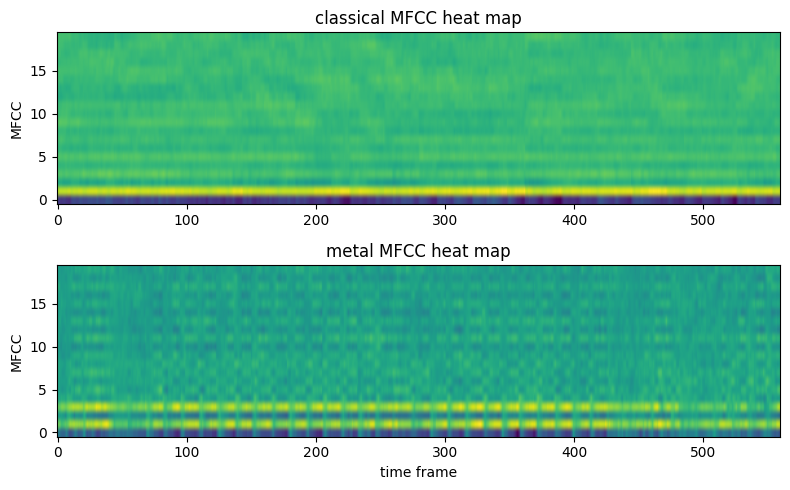

In [4]:
# Visual check: MFCC heat maps (compare with Fig. 1 and 2 of the paper)
fig, ax = plt.subplots(2, 1, figsize=(8, 5))
for a, g in zip(ax, ["classical", "metal"]):
    a.imshow(X[y == GENRES.index(g)][0].T, aspect="auto", origin="lower")
    a.set_title(f"{g} MFCC heat map"); a.set_ylabel("MFCC")
ax[1].set_xlabel("time frame")
plt.tight_layout(); plt.savefig(f"{RES_DIR}/mfcc_examples.png", dpi=150); plt.show()

## 4. Train/test split (80/20, fixed seed, stratified)

In [5]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(X))
tr_idx, te_idx = train_test_split(idx, test_size=0.2, stratify=y, random_state=SEED)
Xtr, Xte, ytr, yte = X[tr_idx], X[te_idx], y[tr_idx], y[te_idx]
print("train:", Xtr.shape, " test:", Xte.shape)

train: (400, 560, 20)  test: (100, 560, 20)


## 5. Classical models
`GDA` is implemented with `LinearDiscriminantAnalysis` (Gaussian class conditionals with a shared covariance, which is exactly GDA). Random Forest uses `max_depth=7` as in the paper; SVM uses an RBF kernel.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

def make_models():
    return {
        "LR":  LogisticRegression(max_iter=2000),
        "GDA": LinearDiscriminantAnalysis(),
        "RF":  RandomForestClassifier(n_estimators=100, max_depth=7, random_state=SEED),
        "SVM": SVC(kernel="rbf", gamma="scale"),
    }

results, preds = [], {}

def run_classical(feature_name, Ftr, Fte):
    if SCALE_FEATURES:
        sc = StandardScaler().fit(Ftr); Ftr, Fte = sc.transform(Ftr), sc.transform(Fte)
    for name, model in make_models().items():
        model.fit(Ftr, ytr)
        tr = accuracy_score(ytr, model.predict(Ftr))
        te_pred = model.predict(Fte)
        te = accuracy_score(yte, te_pred)
        preds[(feature_name, name)] = te_pred
        results.append({"Features": feature_name, "Dim": Ftr.shape[1], "Model": name,
                        "Train": round(tr, 4), "Test": round(te, 4)})
        print(f"{feature_name:12s} {name:4s} train={tr:.3f} test={te:.3f}")

### 5a. Baselines: raw flattened MFCCs and PCA (50 components)

In [7]:
Raw_tr, Raw_te = Xtr.reshape(len(Xtr), -1), Xte.reshape(len(Xte), -1)
run_classical("Raw", Raw_tr, Raw_te)

pca50 = PCA(n_components=50, random_state=SEED).fit(Raw_tr)   # fit on train only
run_classical("PCA-50", pca50.transform(Raw_tr), pca50.transform(Raw_te))

Raw          LR   train=1.000 test=0.700
Raw          GDA  train=0.905 test=0.730
Raw          RF   train=1.000 test=0.760
Raw          SVM  train=0.812 test=0.760
PCA-50       LR   train=0.963 test=0.690
PCA-50       GDA  train=0.850 test=0.780
PCA-50       RF   train=0.985 test=0.710
PCA-50       SVM  train=0.853 test=0.760


## 6. Dilated CNN
Two dilated conv units (`Conv1D(dilation) -> AvgPool -> Dropout(0.5) -> BatchNorm`), then Dense softmax. Adam (lr 0.001), cross-entropy loss. Inputs are normalised per MFCC coefficient using training statistics.

In [8]:
!pip install tensorflow

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

tf.keras.utils.set_random_seed(SEED)

mu  = Xtr.mean(axis=(0, 1), keepdims=True)
std = Xtr.std(axis=(0, 1), keepdims=True) + 1e-8
Ntr, Nte = (Xtr - mu) / std, (Xte - mu) / std

def conv_unit(x, filters, kernel, dilation, pool, name):
    x = layers.Conv1D(filters, kernel, dilation_rate=dilation, padding="same",
                      activation="relu", name=f"{name}_conv")(x)
    x = layers.AveragePooling1D(pool, name=f"{name}_pool")(x)
    x = layers.Dropout(0.5, name=f"{name}_drop")(x)
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    return x

inp = layers.Input((N_FRAMES, N_MFCC))
u1  = conv_unit(inp, filters=8,  kernel=16, dilation=8, pool=32, name="dc1")
u2  = conv_unit(u1,  filters=24, kernel=16, dilation=2, pool=4,  name="dc2")
out = layers.Dense(len(GENRES), activation="softmax")(layers.Flatten()(u2))

cnn = models.Model(inp, out)
cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
            loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn.summary()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 790.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 69.6 MB/s eta 0:00:00


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 560, 20)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dc1_conv (Conv1D)               │ (None, 560, 8)         │         2,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dc1_pool (AveragePooling1D)     │ (None, 17, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dc1_drop (Dropout)              │ (None, 17, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dc1_bn (BatchNormalization)     │ (None, 17, 8)          │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dc2_conv (Conv1D)               │ (None, 17, 24)         │         3,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dc2_pool (AveragePooling1D)     │ (None, 4, 24)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dc2_drop (Dropout)              │ (None, 4, 24)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dc2_bn (BatchNormalization)     │ (None, 4, 24)          │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,277 (24.52 KB)

 Trainable params: 6,213 (24.27 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/150
22/22 - 1s - 63ms/step - accuracy: 0.3059 - loss: 1.8957 - val_accuracy: 0.5000 - val_loss: 1.2895
Epoch 2/150
22/22 - 0s - 6ms/step - accuracy: 0.4588 - loss: 1.3016 - val_accuracy: 0.6000 - val_loss: 1.0443
Epoch 3/150
22/22 - 0s - 7ms/step - accuracy: 0.5265 - loss: 1.1529 - val_accuracy: 0.6167 - val_loss: 0.9070
Epoch 4/150
22/22 - 0s - 6ms/step - accuracy: 0.6118 - loss: 0.9890 - val_accuracy: 0.6167 - val_loss: 0.8167
Epoch 5/150
22/22 - 0s - 7ms/step - accuracy: 0.6588 - loss: 0.8600 - val_accuracy: 0.6833 - val_loss: 0.7485
Epoch 6/150
22/22 - 0s - 6ms/step - accuracy: 0.7059 - loss: 0.7953 - val_accuracy: 0.7167 - val_loss: 0.7048
Epoch 7/150
22/22 - 0s - 6ms/step - accuracy: 0.6853 - loss: 0.7908 - val_accuracy: 0.7167 - val_loss: 0.6677
Epoch 8/150
22/22 - 0s - 6ms/step - accuracy: 0.7029 - loss: 0.7457 - val_accuracy: 0.7167 - val_loss: 0.6398
Epoch 9/150
22/22 - 0s - 6ms/step - accuracy: 0.7088 - loss: 0.7557 - val_accuracy: 0.7333 - val_loss: 0.6059
Epoch 10/

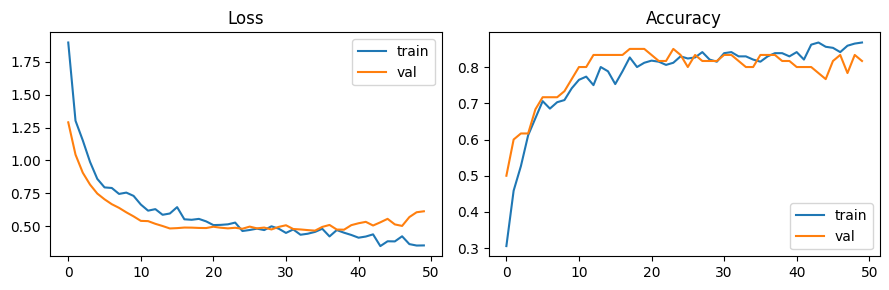

In [9]:
es = callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
hist = cnn.fit(Ntr, ytr, validation_split=0.15, epochs=150, batch_size=16,
               callbacks=[es], verbose=2)

cnn_tr = cnn.evaluate(Ntr, ytr, verbose=0)[1]
cnn_te = cnn.evaluate(Nte, yte, verbose=0)[1]
print(f"\nDCNN  train={cnn_tr:.3f}  test={cnn_te:.3f}")
cnn.save(f"{MODEL_DIR}/dilated_cnn.keras")

plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1); plt.plot(hist.history["loss"], label="train"); plt.plot(hist.history["val_loss"], label="val"); plt.title("Loss"); plt.legend()
plt.subplot(1, 2, 2); plt.plot(hist.history["accuracy"], label="train"); plt.plot(hist.history["val_accuracy"], label="val"); plt.title("Accuracy"); plt.legend()
plt.tight_layout(); plt.savefig(f"{RES_DIR}/cnn_training_curves.png", dpi=150); plt.show()

## 7. Dilated CNN as a feature extractor for the classical models

In [10]:
extractor = models.Model(inp, [u1, u2])
L1_tr, L2_tr = [f.reshape(len(Ntr), -1) for f in extractor.predict(Ntr, verbose=0)]
L1_te, L2_te = [f.reshape(len(Nte), -1) for f in extractor.predict(Nte, verbose=0)]
print("Layer 1 features:", L1_tr.shape[1], " Layer 2 features:", L2_tr.shape[1])

run_classical("DCNN-L1", L1_tr, L1_te)
run_classical("DCNN-L2", L2_tr, L2_te)

Layer 1 features: 136  Layer 2 features: 96
DCNN-L1      LR   train=0.970 test=0.760
DCNN-L1      GDA  train=0.950 test=0.740
DCNN-L1      RF   train=0.990 test=0.790
DCNN-L1      SVM  train=0.915 test=0.810
DCNN-L2      LR   train=0.930 test=0.820
DCNN-L2      GDA  train=0.932 test=0.780
DCNN-L2      RF   train=0.990 test=0.810
DCNN-L2      SVM  train=0.890 test=0.810


## 8. Results table

In [11]:
df = pd.DataFrame(results)
df.loc[len(df)] = ["Raw (end-to-end)", f"{N_FRAMES}x{N_MFCC}", "DCNN", round(cnn_tr, 4), round(cnn_te, 4)]
df.to_csv(f"{RES_DIR}/accuracy_table.csv", index=False)

tbl = df.pivot_table(index=["Features", "Dim"], columns="Model", values=["Train", "Test"])
display(tbl)

Test                         Train                  \
Model                    DCNN   GDA    LR    RF   SVM  DCNN     GDA      LR   
Features         Dim                                                          
DCNN-L1          136      NaN  0.74  0.76  0.79  0.81   NaN  0.9500  0.9700   
DCNN-L2          96       NaN  0.78  0.82  0.81  0.81   NaN  0.9325  0.9300   
PCA-50           50       NaN  0.78  0.69  0.71  0.76   NaN  0.8500  0.9625   
Raw              11200    NaN  0.73  0.70  0.76  0.76   NaN  0.9050  1.0000   
Raw (end-to-end) 560x20  0.78   NaN   NaN   NaN   NaN  0.87     NaN     NaN   

                                        
Model                       RF     SVM  
Features         Dim                    
DCNN-L1          136     0.990  0.9150  
DCNN-L2          96      0.990  0.8900  
PCA-50           50      0.985  0.8525  
Raw              11200   1.000  0.8125  
Raw (end-to-end) 560x20    NaN     NaN

## 9. Confusion matrices

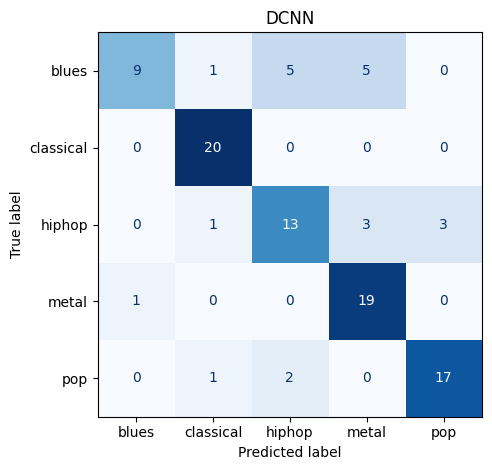

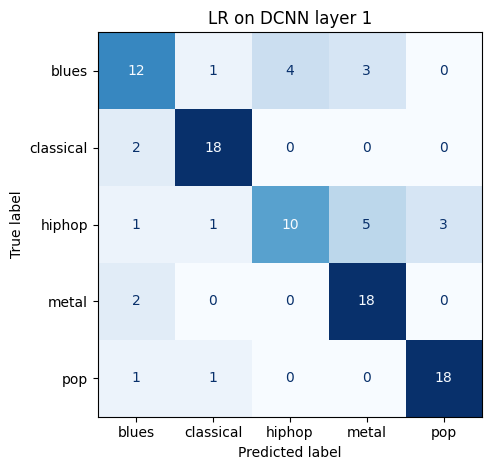

In [12]:
def plot_cm(y_true, y_pred, title, fname):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=GENRES).plot(cmap="Blues", colorbar=False)
    plt.title(title); plt.tight_layout(); plt.savefig(f"{RES_DIR}/{fname}", dpi=150); plt.show()

plot_cm(yte, cnn.predict(Nte, verbose=0).argmax(1), "DCNN", "cnn_confusion_matrix.png")
plot_cm(yte, preds[("DCNN-L1", "LR")], "LR on DCNN layer 1", "lr_confusion_matrix.png")

## 10. PCA visualisation (3D) of test-set features

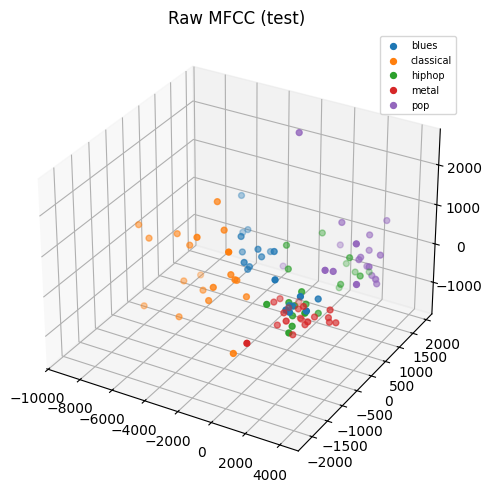

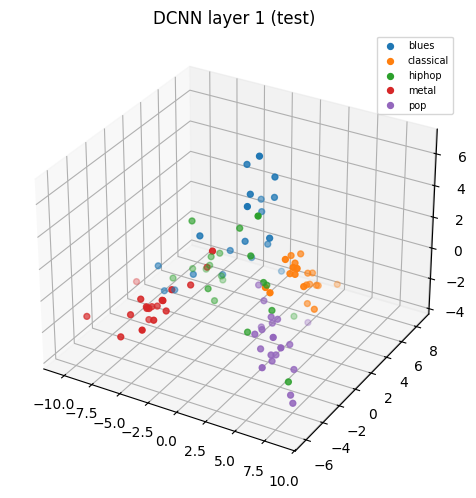

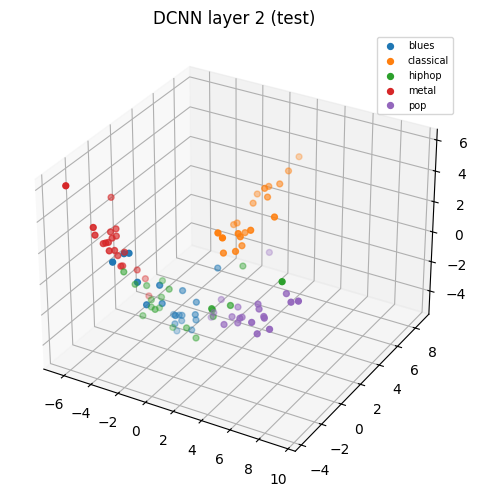

In [13]:
def pca3d(F, title, fname):
    Z = PCA(n_components=3, random_state=SEED).fit_transform(F)
    fig = plt.figure(figsize=(6, 5)); ax = fig.add_subplot(111, projection="3d")
    for i, g in enumerate(GENRES):
        ax.scatter(*Z[yte == i].T, label=g, s=18)
    ax.set_title(title); ax.legend(fontsize=7)
    plt.tight_layout(); plt.savefig(f"{RES_DIR}/{fname}", dpi=150); plt.show()

pca3d(Raw_te, "Raw MFCC (test)", "pca_raw.png")
pca3d(L1_te,  "DCNN layer 1 (test)", "pca_layer1.png")
pca3d(L2_te,  "DCNN layer 2 (test)", "pca_layer2.png")

## 11. Output zip file

In [14]:
!cd {REPO_DIR} && zip -r -q /content/outputs.zip features models results
from google.colab import files
files.download("/content/outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>